Epoch 1/15


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 0.0590 - val_loss: 0.0336
Epoch 2/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0150 - val_loss: 0.0282
Epoch 3/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0096 - val_loss: 0.0037
Epoch 4/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0084 - val_loss: 0.0091
Epoch 5/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0083 - val_loss: 0.0034
Epoch 6/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0071 - val_loss: 0.0034
Epoch 7/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0067 - val_loss: 0.0034
Epoch 8/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0055 - val_loss: 0.0033
Epoch 9/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0057 - val_loss: 0.0035
Epoch 10/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0051 - val_loss: 0.0033
Epoch 11/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0055 - val_loss: 0.0030
Epoch 12/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0044 - val_l

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step 
MAE: 2.831
RMSE: 3.672


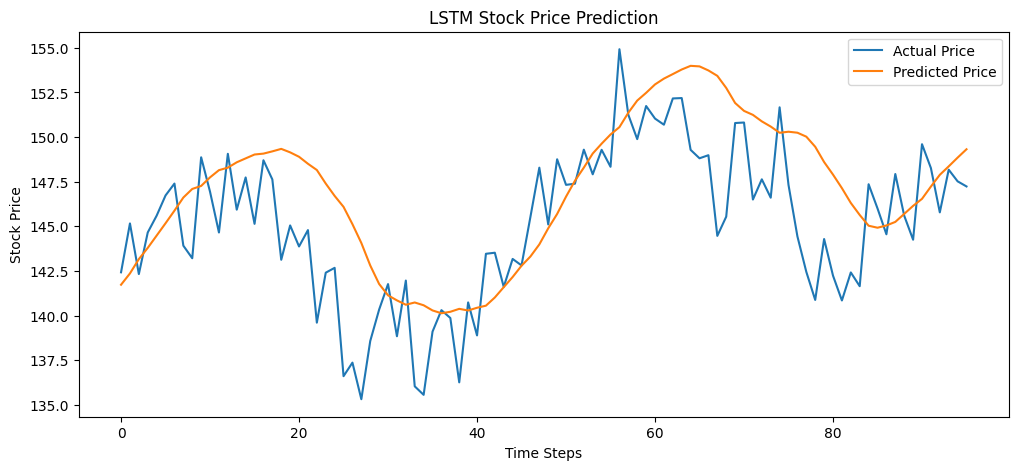

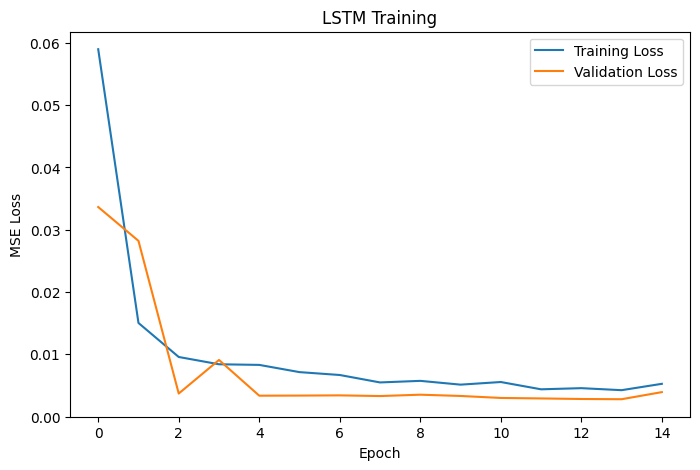

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

np.random.seed(42)
tf.random.set_seed(42)

days = 500

trend = np.linspace(100, 150, days)
seasonal = 5 * np.sin(np.linspace(0, 20 * np.pi, days))
noise = np.random.normal(0, 2, days)

stock_price = trend + seasonal + noise

data = pd.DataFrame({
    "Day": np.arange(days),
    "Close": stock_price
})

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(
    data[["Close"]]
)

sequence_length = 20

X = []
y = []

for i in range(
    sequence_length,
    len(scaled_data)
):
    X.append(
        scaled_data[
            i-sequence_length:i,
            0
        ]
    )
    y.append(
        scaled_data[i, 0]
    )

X = np.array(X)
y = np.array(y)

X = X.reshape(
    X.shape[0],
    X.shape[1],
    1
)

split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

model = Sequential([
    LSTM(
        64,
        return_sequences=True,
        input_shape=(sequence_length, 1)
    ),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse"
)

history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.1
)

predicted = model.predict(X_test)

predicted = scaler.inverse_transform(predicted)

actual = scaler.inverse_transform(
    y_test.reshape(-1, 1)
)

mae = mean_absolute_error(
    actual,
    predicted
)

rmse = np.sqrt(
    mean_squared_error(
        actual,
        predicted
    )
)

print("MAE:", round(mae, 3))
print("RMSE:", round(rmse, 3))

plt.figure(figsize=(12, 5))
plt.plot(
    actual,
    label="Actual Price"
)
plt.plot(
    predicted,
    label="Predicted Price"
)
plt.xlabel("Time Steps")
plt.ylabel("Stock Price")
plt.title("LSTM Stock Price Prediction")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(
    history.history["loss"],
    label="Training Loss"
)
plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Training")
plt.legend()
plt.show()